# Сравнение SigLIP 2 до и после дообучения

Ноутбук строит два эталонных эмбеддинга для каждого товара (этикетка и вся бутылка) для обеих версий SigLIP 2, сохраняет их в CSV, затем обрабатывает тестовые фото: детектирует бутылку, вырезает этикетку и ищет совпадения. Если этикетка не найдена, используется вектор полной бутылки.

Модель не дообучается повторно. Укажите пути и запустите ячейки сверху вниз. Для оценки точности имена тестовых файлов или имена их папок должны совпадать с названием товара; иначе задайте `TARGET_BY_FILENAME` вручную.

In [1]:
%pip install -q ultralytics opencv-python-headless transformers accelerate pillow matplotlib pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 5.2 MB/s eta 0:00:00


In [3]:
from pathlib import Path
import glob
import json
import re
import unicodedata
import gc

import cv2
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from ultralytics import YOLO
from transformers import AutoModel, AutoProcessor

try:
    from google.colab import drive
    if not Path('/content/drive/MyDrive').exists():
        drive.mount('/content/drive')
except ImportError:
    pass

In [6]:
ROOT_DIR = Path('/content/drive/MyDrive/WineCV')
IMAGES_DIR = ROOT_DIR / 'wine_images'
TEST_DIR = ROOT_DIR / 'field_test'
LABEL_MODEL_PATH = ROOT_DIR / 'models' / 'label_pose_best.pt'
FINETUNED_PATH = ROOT_DIR / 'models' / 'siglip2_finetuned.pt'
BOTTLE_MODEL_PATH = None  # Можно указать Path к best.pt модели detect вручную
CSV_PATH = ROOT_DIR / 'embedding_comparison_reference.csv'
BASE_MODEL_ID = 'google/siglip2-base-patch16-384'
BOTTLE_CONFIDENCE = 0.25
LABEL_CONFIDENCE = 0.5
LABEL_OUTPUT_SIZE = (400, 600)  # ширина, высота
TOP_K = 5
TARGET_BY_FILENAME = {}  # например: {'photo_001.jpg': 'Название товара'}
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

if BOTTLE_MODEL_PATH is None:
    bottle_candidates = [
        ROOT_DIR / 'models_bottle' / 'label_train-2' / 'weights' / 'best.pt',
        Path('/content/drive/MyDrive/WineCV/models_bottle/label_train-2/weights/best.pt'),
    ]
    bottle_candidates += [Path(p) for root in (ROOT_DIR / 'models_bottle', Path('/content/drive/MyDrive/WineCV/models_bottle'))
                         for p in glob.glob(str(root / '**' / 'weights' / 'best.pt'), recursive=True)]
    BOTTLE_MODEL_PATH = next((p for p in bottle_candidates if p.is_file()), bottle_candidates[0])
else:
    BOTTLE_MODEL_PATH = Path(BOTTLE_MODEL_PATH)

required_paths = [IMAGES_DIR, TEST_DIR, LABEL_MODEL_PATH, FINETUNED_PATH, BOTTLE_MODEL_PATH]
missing = [str(path) for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError('Не найдены необходимые папки/веса:\n' + '\n'.join(missing) +
                          '\nПроверьте ROOT_DIR и BOTTLE_MODEL_PATH в ячейке конфигурации.')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Устройство: {device}')
print(f'Эталонные изображения: {IMAGES_DIR}')
print(f'Тестовые изображения: {TEST_DIR}')
print(f'Детектор бутылок: {BOTTLE_MODEL_PATH}')
print(f'Детектор этикеток: {LABEL_MODEL_PATH}')
print(f'Checkpoint SigLIP: {FINETUNED_PATH}')

Устройство: cuda
Эталонные изображения: /content/drive/MyDrive/WineCV/wine_images
Тестовые изображения: /content/drive/MyDrive/WineCV/field_test
Детектор бутылок: /content/drive/MyDrive/WineCV/models_bottle/label_train-2/weights/best.pt
Детектор этикеток: /content/drive/MyDrive/WineCV/models/label_pose_best.pt
Checkpoint SigLIP: /content/drive/MyDrive/WineCV/models/siglip2_finetuned.pt


In [7]:
def normalize_name(value):
    value = unicodedata.normalize('NFKC', str(value)).casefold()
    value = re.sub(r'[_-]+', ' ', value)
    return ' '.join(value.split())

def classname_from_path(path):
    return normalize_name(Path(path).stem)

def read_rgb(path):
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError(f'Не удалось прочитать изображение: {path}')
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def order_points(points):
    points = np.asarray(points, dtype=np.float32)[:4]
    if points.shape != (4, 2) or not np.isfinite(points).all():
        raise ValueError('Для перспективного кропа нужны 4 корректные keypoints')
    ordered = np.zeros((4, 2), dtype=np.float32)
    sums = points.sum(axis=1)
    diffs = np.diff(points, axis=1).ravel()
    ordered[0], ordered[2] = points[np.argmin(sums)], points[np.argmax(sums)]
    ordered[1], ordered[3] = points[np.argmin(diffs)], points[np.argmax(diffs)]
    return ordered

def label_crop(image_rgb, model):
    result = model.predict(cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR), conf=LABEL_CONFIDENCE, verbose=False)[0]
    if result.keypoints is None or len(result.keypoints.xy) == 0:
        return None
    best = int(result.boxes.conf.argmax()) if result.boxes is not None and len(result.boxes) else 0
    try:
        corners = order_points(result.keypoints.xy[best].cpu().numpy())
    except (ValueError, IndexError):
        return None
    width, height = LABEL_OUTPUT_SIZE
    destination = np.float32([[0, 0], [width - 1, 0], [width - 1, height - 1], [0, height - 1]])
    matrix = cv2.getPerspectiveTransform(corners, destination)
    return cv2.warpPerspective(image_rgb, matrix, (width, height))

def load_siglip():
    dtype = torch.float16 if device == 'cuda' else torch.float32
    processor = AutoProcessor.from_pretrained(BASE_MODEL_ID)
    model = AutoModel.from_pretrained(BASE_MODEL_ID, torch_dtype=dtype).to(device).eval()
    return model, processor

def load_finetuned_weights(model):
    try:
        checkpoint = torch.load(FINETUNED_PATH, map_location='cpu', weights_only=True)
    except TypeError:
        checkpoint = torch.load(FINETUNED_PATH, map_location='cpu')
    if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
        checkpoint = checkpoint['state_dict']
    model.load_state_dict(checkpoint, strict=True)
    model.eval()
    print(f'Fine-tuned state_dict загружен строго: {FINETUNED_PATH}')
    return model

@torch.inference_mode()
def embed_image(model, processor, image_rgb):
    inputs = processor(images=image_rgb, return_tensors='pt')
    inputs = {key: value.to(device) for key, value in inputs.items()}
    if device == 'cuda':
        inputs = {key: value.half() if value.is_floating_point() else value for key, value in inputs.items()}
    features = model.get_image_features(**inputs)
    if not torch.is_tensor(features):
        features = getattr(features, 'pooler_output', None)
        if features is None:
            raise RuntimeError('SigLIP не вернул pooled image features')
    if features.ndim == 3:
        features = features.mean(dim=1)
    features = torch.nn.functional.normalize(features.float(), p=2, dim=-1)
    return features[0].cpu().numpy()

def serialize_vector(vector):
    return json.dumps(np.asarray(vector, dtype=np.float32).tolist(), separators=(',', ':'))

def list_images(folder):
    return sorted(path for path in Path(folder).rglob('*') if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS)

bottle_model = YOLO(str(BOTTLE_MODEL_PATH))
label_model = YOLO(str(LABEL_MODEL_PATH))
if bottle_model.task != 'detect':
    raise ValueError(f'Ожидалась YOLO detect-модель бутылки, получена: {bottle_model.task}')
if label_model.task != 'pose':
    raise ValueError(f'Ожидалась YOLO pose-модель этикетки, получена: {label_model.task}')
print('YOLO detect и pose модели загружены.')

YOLO detect и pose модели загружены.


## Эталонные векторы
Для каждого изображения формируются эмбеддинги вырезанной этикетки и полного исходного изображения. Если на эталоне этикетка не обнаружена, в поле label сохраняется эмбеддинг полного изображения, а факт fallback отмечается отдельно.

In [8]:
reference_paths = list_images(IMAGES_DIR)
if not reference_paths:
    raise FileNotFoundError(f'В {IMAGES_DIR} нет поддерживаемых изображений')

reference_rows = []
model, processor = load_siglip()
print(f'Строю baseline-эмбеддинги для {len(reference_paths)} эталонов...')
for index, path in enumerate(reference_paths, 1):
    try:
        image = read_rgb(path)
        cropped_label = label_crop(image, label_model)
        reference_rows.append({
            'classname': classname_from_path(path),
            'filename': path.name,
            'path': str(path),
            'label_found_in_reference': cropped_label is not None,
            'embedding_label_base': serialize_vector(embed_image(model, processor, cropped_label if cropped_label is not None else image)),
            'embedding_full_base': serialize_vector(embed_image(model, processor, image)),
        })
    except Exception as error:
        print(f'[WARN] Эталон пропущен {path.name}: {error}')
    if index % 20 == 0 or index == len(reference_paths):
        print(f'Baseline: {index}/{len(reference_paths)}')
if not reference_rows:
    raise RuntimeError('Не удалось получить ни одного эталонного вектора')

print('Загружаю fine-tuned state_dict для построения эмбеддингов...')
load_finetuned_weights(model)
for index, row in enumerate(reference_rows, 1):
    image = read_rgb(row['path'])
    cropped_label = label_crop(image, label_model)
    row['embedding_label_finetuned'] = serialize_vector(embed_image(model, processor, cropped_label if cropped_label is not None else image))
    row['embedding_full_finetuned'] = serialize_vector(embed_image(model, processor, image))
    if index % 20 == 0 or index == len(reference_rows):
        print(f'Fine-tuned: {index}/{len(reference_rows)}')

columns = ['classname', 'filename', 'path', 'label_found_in_reference', 'embedding_label_base', 'embedding_full_base', 'embedding_label_finetuned', 'embedding_full_finetuned']
reference_df = pd.DataFrame(reference_rows, columns=columns)
reference_df.to_csv(CSV_PATH, index=False, encoding='utf-8')
print(f'Эталонный CSV сохранён: {CSV_PATH} ({len(reference_df)} товаров)')

# Дальше retrieval использует именно сохранённый CSV, а не временные записи в памяти.
reference_df = pd.read_csv(CSV_PATH, encoding='utf-8')
for column in ['embedding_label_base', 'embedding_full_base', 'embedding_label_finetuned', 'embedding_full_finetuned']:
    reference_df[column + '_array'] = reference_df[column].map(json.loads)
pd.set_option('display.max_colwidth', 48)
print('Первые 5 строк сохранённого CSV (длинные векторы отображены сокращённо):')
display(reference_df[columns].head(5))

preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/276 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


tokenizer_config.json:   0%|          | 0.00/47.2k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 34.4MB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.50GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Строю baseline-эмбеддинги для 1681 эталонов...
Baseline: 20/1681
Baseline: 40/1681
Baseline: 60/1681
Baseline: 80/1681
Baseline: 100/1681
Baseline: 120/1681
Baseline: 140/1681
Baseline: 160/1681
Baseline: 180/1681
Baseline: 200/1681
Baseline: 220/1681
Baseline: 240/1681
Baseline: 260/1681
Baseline: 280/1681
Baseline: 300/1681
Baseline: 320/1681
Baseline: 340/1681
Baseline: 360/1681
Baseline: 380/1681
Baseline: 400/1681
Baseline: 420/1681
Baseline: 440/1681
Baseline: 460/1681
Baseline: 480/1681
Baseline: 500/1681
Baseline: 520/1681
Baseline: 540/1681
Baseline: 560/1681
Baseline: 580/1681
Baseline: 600/1681
Baseline: 620/1681
Baseline: 640/1681
Baseline: 660/1681
Baseline: 680/1681
Baseline: 700/1681
Baseline: 720/1681
Baseline: 740/1681
Baseline: 760/1681
Baseline: 780/1681
Baseline: 800/1681
Baseline: 820/1681
Baseline: 840/1681
Baseline: 860/1681
Baseline: 880/1681
Baseline: 900/1681
Baseline: 920/1681
Baseline: 940/1681
Baseline: 960/1681
Baseline: 980/1681
Baseline: 1000/1681
Baseli

,classname,filename,path,label_found_in_reference,embedding_label_base,embedding_full_base,embedding_label_finetuned,embedding_full_finetuned
0,100 оттенков шардоне,100_оттенков_Шардоне.webp,/content/drive/MyDrive/WineCV/wine_images/10...,True,"[-0.031167957931756973,0.031444672495126724,...","[-0.0304692555218935,0.002094761235639453,-0...","[0.04634175822138786,0.060288213193416595,-0...","[0.04313453286886215,0.06957392394542694,-0...."
1,100 оттенков красного каберне,100_оттенков_красного_Каберне.webp,/content/drive/MyDrive/WineCV/wine_images/10...,True,"[-0.04410295560956001,0.0237595122307539,-0....","[-0.04186433181166649,0.0024674583692103624,...","[0.049251094460487366,0.0512244738638401,-0....","[0.04428544640541077,0.0591781847178936,-0.0..."
2,100 оттенков красного пино нуар,100_оттенков_красного_Пино_Нуар.webp,/content/drive/MyDrive/WineCV/wine_images/10...,True,"[-0.06241583824157715,0.015565304085612297,-...","[-0.04873756691813469,-0.007406530436128378,...","[0.04269655421376228,0.04196992889046669,-0....","[0.012668540701270103,0.019221235066652298,-..."
3,100 оттенков красного саперави,100_оттенков_красного_Саперави.webp,/content/drive/MyDrive/WineCV/wine_images/10...,True,"[-0.0491238497197628,0.021474355831742287,-0...","[-0.046505119651556015,0.004761595278978348,...","[0.04873558133840561,0.053085487335920334,-0...","[0.04606286808848381,0.05977049842476845,-0...."
4,101 оттенок красного каберне,101_оттенок_красного_Каберне.webp,/content/drive/MyDrive/WineCV/wine_images/10...,True,"[-0.05050521343946457,0.0043055210262537,-0....","[-0.03673520311713219,-0.019082024693489075,...","[0.05974283069372177,0.04596957191824913,-0....","[0.033900707960128784,0.03071853704750538,-0..."


## Подготовка field test
Детекция запускается один раз на изображение. Для retrieval при отсутствии бутылки используется исходное фото, а при найденной бутылке, но ненайденной этикетке, используется кроп бутылки.

In [9]:
def find_bottle_crop(image_rgb):
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    result = bottle_model.predict(image_bgr, conf=BOTTLE_CONFIDENCE, verbose=False)[0]
    if result.boxes is None or len(result.boxes) == 0:
        return None
    best = int(result.boxes.conf.argmax())
    x1, y1, x2, y2 = result.boxes.xyxy[best].cpu().numpy().astype(int)
    height, width = image_rgb.shape[:2]
    x1, x2 = max(0, x1), min(width, x2)
    y1, y2 = max(0, y1), min(height, y2)
    return image_rgb[y1:y2, x1:x2].copy() if x2 > x1 and y2 > y1 else None


test_paths = list_images(TEST_DIR)
if not test_paths:
    raise FileNotFoundError(f'В {TEST_DIR} нет поддерживаемых изображений')

test_items = []
for path in test_paths:
    try:
        original = read_rgb(path)
        bottle = find_bottle_crop(original)
        bottle_found = bottle is not None
        bottle_or_photo = bottle if bottle_found else original
        cropped_label = label_crop(bottle_or_photo, label_model) if bottle_found else None
        test_items.append({
            'path': path,
            'original': original,
            'bottle_crop': bottle_or_photo,
            'label_crop': cropped_label,
            'bottle_found': bottle_found,
            'label_found': cropped_label is not None,
        })
    except Exception as error:
        print(f'[WARN] Тестовое фото пропущено {path.name}: {error}')

if not test_items:
    raise RuntimeError('Не удалось подготовить тестовые изображения')

print(f'Подготовлено тестовых изображений: {len(test_items)}')

Подготовлено тестовых изображений: 9


## Сравнение моделей

Baseline и fine-tuned используют одни и те же тестовые кропы. Метрика считается только для изображений, где target удалось однозначно сопоставить с классом; similarity служит для ранжирования, а не является вероятностью.

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Вычисляю test query эмбеддинги baseline модели...
Fine-tuned state_dict загружен строго: /content/drive/MyDrive/WineCV/models/siglip2_finetuned.pt
Вычисляю test query эмбеддинги fine-tuned модели...
5307699530927121833.jpg | бутылка: True | этикетка: True | режим: label
  baseline:   victor dravigny extra brut (0.843), victor dravigny красное полусладкое (0.794), империал кюве (0.775), абрау дюрсо удельное ведомство императорское белое полусладкое (0.774), victor dravigny brut rose (0.764)
  fine-tuned: victor dravigny полусухое (0.946), victor dravigny brut rose (0.936), victor dravigny полусладкое (0.915), куприн (0.859), шереметьевские погреба шардоне (0.753)


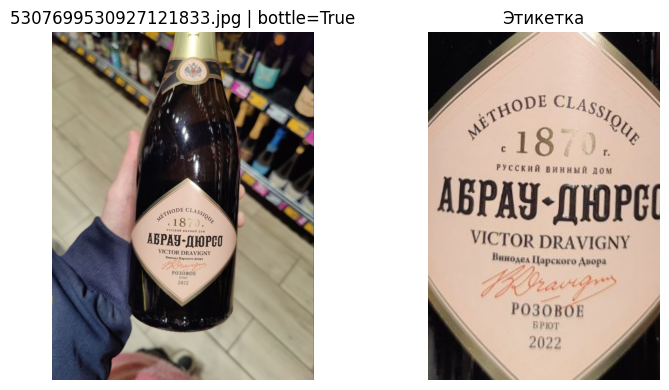

5307699530927121834.jpg | бутылка: True | этикетка: True | режим: label
  baseline:   victor dravigny extra brut (0.825), victor dravigny красное полусладкое (0.785), victor dravigny полусладкое (0.774), victor dravigny полусухое (0.768), victor dravigny brut rose (0.768)
  fine-tuned: victor dravigny полусухое (0.893), victor dravigny brut rose (0.890), victor dravigny полусладкое (0.858), куприн (0.850), шереметьевские погреба шардоне (0.760)


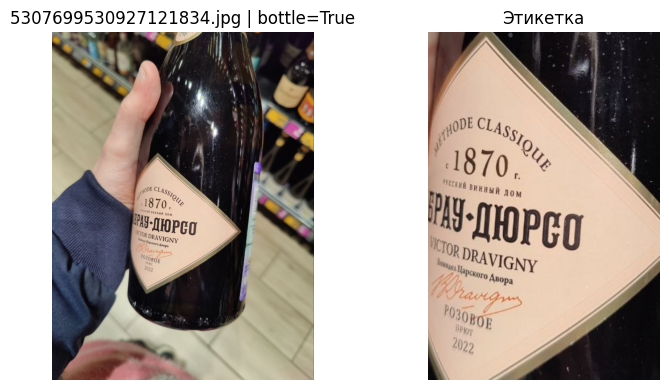

5307699530927121835.jpg | бутылка: True | этикетка: True | режим: label
  baseline:   quintessence вионье (0.852), quintessence reserve пино нуар (0.823), quintessence new generation темпранильо (0.819), quintessence гевюрцтраминер (0.816), quintessence карменер (0.813)
  fine-tuned: quintessence storm шираз (0.967), глера манно (0.953), quintessence new generation совиньон блан (0.952), quintessence алиготе (0.951), quintessence гевюрцтраминер (0.948)


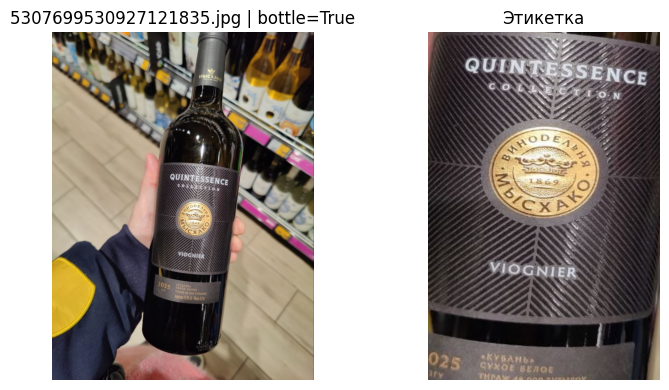

5307699530927121836.jpg | бутылка: True | этикетка: True | режим: label
  baseline:   quintessence вионье (0.833), quintessence new generation темпранильо (0.818), quintessence reserve пино нуар (0.801), quintessence зинфандель (0.800), quintessence карменер (0.797)
  fine-tuned: quintessence storm шираз (0.975), quintessence new generation совиньон блан (0.940), quintessence алиготе (0.936), quintessence new generation каберне фран (0.932), quintessence гевюрцтраминер (0.931)


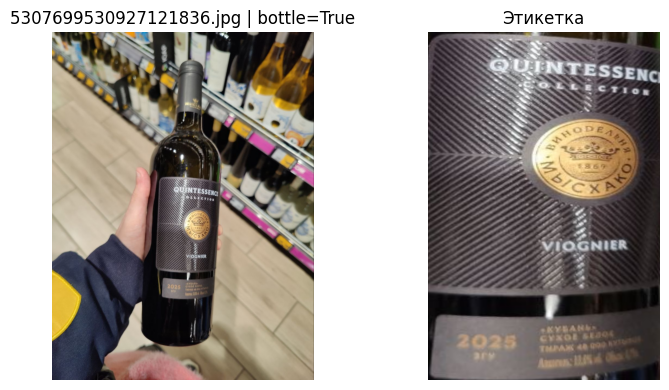

5307699530927121837.jpg | бутылка: True | этикетка: True | режим: label
  baseline:   мускат белый южнобережный (0.863), мускатель розовый (0.839), мускатель белый (0.823), мускатель черный (0.817), портвейн красный ливадия (0.813)
  fine-tuned: мускат белый южнобережный (0.985), портвейн красный ливадия (0.984), мускатель розовый (0.964), мускатель черный (0.963), лакрима кристи (0.955)


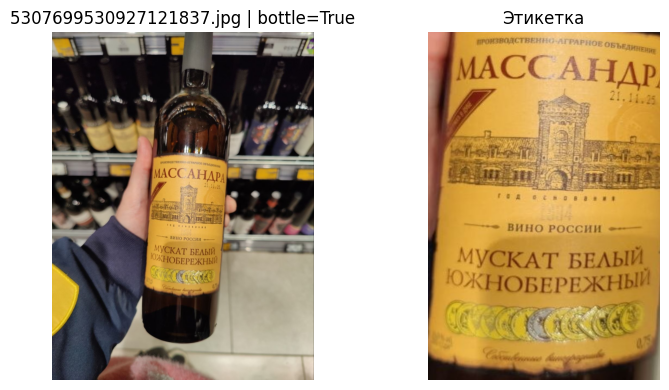

5307699530927121838.jpg | бутылка: True | этикетка: False | режим: full fallback
  baseline:   уроки французского мерло (0.850), уроки французского красностоп (0.846), уроки французского сира (0.841), уроки французского совиньон блан (0.819), уроки французского шардоне (0.815)
  fine-tuned: уроки французского мерло (0.904), уроки французского каберне фран (0.828), уроки французского сира (0.804), уроки французского каберне совиньон (0.770), уроки французского шардоне (0.762)


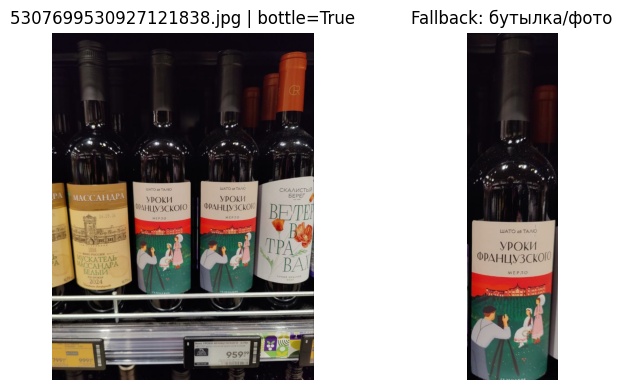

5307699530927121839.jpg | бутылка: True | этикетка: True | режим: label
  baseline:   пино нуар резерв (0.840), каберне фран 1890 (0.785), каберне совиньон мерло 1890 (0.781), пино нуар семейный резерв (0.780), алиготе лимитированная серия (0.774)
  fine-tuned: a g poezdnik красное (0.934), agora vintage blanc de blancs extra brut (0.896), a g poezdnik белое (0.878), игристое вино выдержанное брют розовое новый свет пино фран (0.851), игристое вино выдержанное полусладкое розовое новый свет пино фран (0.851)


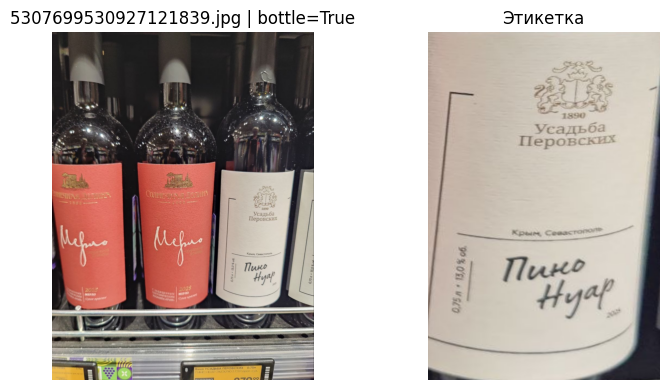

5307699530927121840.jpg | бутылка: True | этикетка: True | режим: label
  baseline:   millstream av игристое молодое полусухое белое (0.704), фанагория белое полусладкое (0.683), империал brut l art nouveau (0.683), millstream av игристое молодое сухое белое (0.680), шардоне премиум (0.679)
  fine-tuned: союз вино шардоне сухое (0.732), алиготе авторское валерий захарьин (0.705), rose cuvee prestige de gai kodzor (0.689), фанагория белое полусладкое (0.687), гай кодзор русан (0.679)


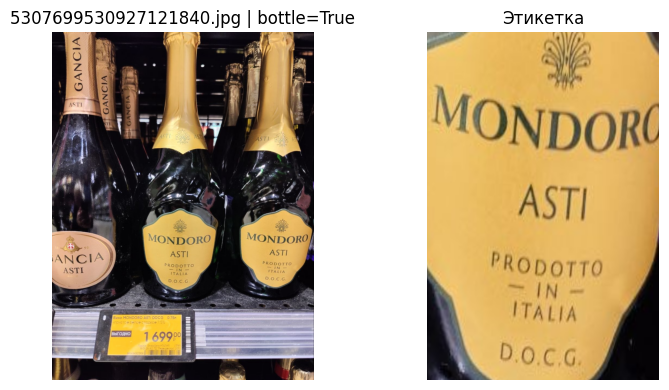

5307699530927121841.jpg | бутылка: True | этикетка: True | режим: label
  baseline:   brut d or blanc de blancs (0.851), brut d or riesling (0.816), brut d or blanc de noirs (0.794), brut d or rose (0.789), mont blanc blanc de blancs (0.735)
  fine-tuned: brut d or blanc de blancs (0.994), brut d or riesling (0.992), игристое вино выдержанное брют розовое новый свет пино фран (0.942), игристое вино выдержанное полусладкое розовое новый свет пино фран (0.924), игристое вино выдержанное брют розовое новый свет пино нуар (0.919)


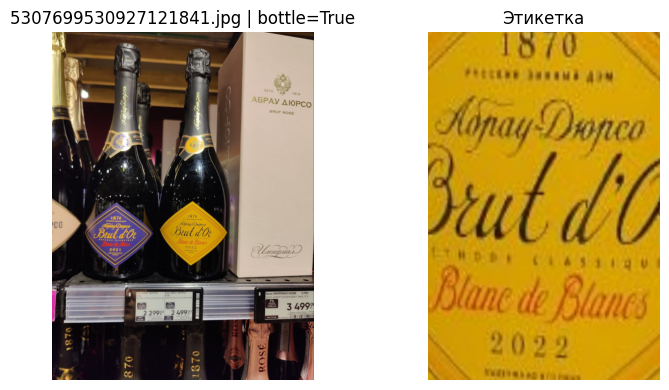

,filename,bottle_found,label_found,fallback_used,baseline_top1,baseline_top1_similarity,finetuned_top1,finetuned_top1_similarity
0,5307699530927121833.jpg,True,True,False,victor dravigny extra brut,0.842674,victor dravigny полусухое,0.946266
1,5307699530927121834.jpg,True,True,False,victor dravigny extra brut,0.824798,victor dravigny полусухое,0.892785
2,5307699530927121835.jpg,True,True,False,quintessence вионье,0.851669,quintessence storm шираз,0.966824
3,5307699530927121836.jpg,True,True,False,quintessence вионье,0.832564,quintessence storm шираз,0.975368
4,5307699530927121837.jpg,True,True,False,мускат белый южнобережный,0.863406,мускат белый южнобережный,0.984966
5,5307699530927121838.jpg,True,False,True,уроки французского мерло,0.849920,уроки французского мерло,0.904185
6,5307699530927121839.jpg,True,True,False,пино нуар резерв,0.839830,a g poezdnik красное,0.934108
7,5307699530927121840.jpg,True,True,False,millstream av игристое молодое полусухое белое,0.704093,союз вино шардоне сухое,0.732177
8,5307699530927121841.jpg,True,True,False,brut d or blanc de blancs,0.851061,brut d or blanc de blancs,0.994007



Accuracy рассчитывается по 0 из 9 фото с определённым target.
Нет однозначно размеченных фото. Укажите соответствия в TARGET_BY_FILENAME.
Сводка тестов сохранена: /content/drive/MyDrive/WineCV/field_test_siglip_comparison.csv


In [10]:
classes = reference_df['classname'].astype(str).tolist()
reference_matrices = {
    'base_label': np.asarray(reference_df['embedding_label_base_array'].tolist(), dtype=np.float32),
    'base_full': np.asarray(reference_df['embedding_full_base_array'].tolist(), dtype=np.float32),
    'finetuned_label': np.asarray(reference_df['embedding_label_finetuned_array'].tolist(), dtype=np.float32),
    'finetuned_full': np.asarray(reference_df['embedding_full_finetuned_array'].tolist(), dtype=np.float32),
}


def rank_predictions(query, model_key, use_label, k=TOP_K):
    matrix_key = f'{model_key}_label' if use_label else f'{model_key}_full'
    scores = reference_matrices[matrix_key] @ query
    indices = np.argsort(-scores)[:k]
    return [(classes[i], float(scores[i])) for i in indices]


def infer_target(item):
    path = item['path']
    override = TARGET_BY_FILENAME.get(path.name, TARGET_BY_FILENAME.get(path.stem))
    known = set(classes)
    if override is not None:
        target = normalize_name(override)
        return target if target in known else None
    parent = normalize_name(path.parent.name)
    if path.parent != TEST_DIR and parent in known:
        return parent
    stem = normalize_name(path.stem)
    return stem if stem in known else None


model, processor = load_siglip()
print('Вычисляю test query эмбеддинги baseline модели...')
for item in test_items:
    source = item['label_crop'] if item['label_found'] else item['bottle_crop']
    item['query_base'] = embed_image(model, processor, source)

load_finetuned_weights(model)
print('Вычисляю test query эмбеддинги fine-tuned модели...')
for item in test_items:
    source = item['label_crop'] if item['label_found'] else item['bottle_crop']
    item['query_finetuned'] = embed_image(model, processor, source)

del model, processor
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

result_rows = []
for item in test_items:
    base_preds = rank_predictions(item['query_base'], 'base', item['label_found'])
    fine_preds = rank_predictions(item['query_finetuned'], 'finetuned', item['label_found'])
    target = infer_target(item)
    row = {
        'filename': item['path'].name,
        'bottle_found': item['bottle_found'],
        'label_found': item['label_found'],
        'fallback_used': not item['label_found'],
        'target': target,
        'baseline_top1': base_preds[0][0],
        'baseline_top1_similarity': base_preds[0][1],
        'finetuned_top1': fine_preds[0][0],
        'finetuned_top1_similarity': fine_preds[0][1],
        'baseline_top5': [name for name, _ in base_preds],
        'finetuned_top5': [name for name, _ in fine_preds],
    }
    result_rows.append(row)
    print(f"{row['filename']} | бутылка: {item['bottle_found']} | этикетка: {item['label_found']} | режим: {'label' if item['label_found'] else 'full fallback'}")
    print('  baseline:   ' + ', '.join(f'{name} ({score:.3f})' for name, score in base_preds))
    print('  fine-tuned: ' + ', '.join(f'{name} ({score:.3f})' for name, score in fine_preds))

    figure, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(item['original'])
    axes[0].set_title(f"{row['filename']} | bottle={item['bottle_found']}")
    axes[0].axis('off')
    axes[1].imshow(item['label_crop'] if item['label_found'] else item['bottle_crop'])
    axes[1].set_title('Этикетка' if item['label_found'] else 'Fallback: бутылка/фото')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
    plt.close(figure)

results_df = pd.DataFrame(result_rows)
display(results_df[['filename', 'bottle_found', 'label_found', 'fallback_used', 'baseline_top1', 'baseline_top1_similarity', 'finetuned_top1', 'finetuned_top1_similarity']])
scored = results_df[results_df['target'].notna()]
print(f'\nAccuracy рассчитывается по {len(scored)} из {len(results_df)} фото с определённым target.')
if len(scored):
    for model_key in ('baseline', 'finetuned'):
        top1 = (scored[f'{model_key}_top1'] == scored['target']).mean()
        top5 = scored.apply(lambda row: row['target'] in row[f'{model_key}_top5'], axis=1).mean()
        print(f'{model_key}: Top-1={top1:.3f}, Top-5={top5:.3f}')
else:
    print('Нет однозначно размеченных фото. Укажите соответствия в TARGET_BY_FILENAME.')

RESULTS_PATH = ROOT_DIR / 'field_test_siglip_comparison.csv'
results_df.drop(columns=['baseline_top5', 'finetuned_top5']).to_csv(RESULTS_PATH, index=False, encoding='utf-8')
print(f'Сводка тестов сохранена: {RESULTS_PATH}')

In [11]:
AUGMENTATION_SEED = 2026
AUGMENTATION_TYPES = ('lighting', 'rotation_blur', 'noise_occlusion')


def make_benchmark_augmentation(image_rgb, augmentation_name, seed):
    rng = np.random.default_rng(seed)
    image = image_rgb.astype(np.float32)
    height, width = image.shape[:2]

    if augmentation_name == 'lighting':
        brightness = rng.uniform(-28, 28)
        contrast = rng.uniform(0.75, 1.25)
        image = (image - 127.5) * contrast + 127.5 + brightness
    elif augmentation_name == 'rotation_blur':
        angle = rng.uniform(-12, 12)
        scale = rng.uniform(0.92, 1.08)
        matrix = cv2.getRotationMatrix2D((width / 2, height / 2), angle, scale)
        image = cv2.warpAffine(image, matrix, (width, height), borderMode=cv2.BORDER_REFLECT101)
        image = cv2.GaussianBlur(image, (3, 3), 0)
    elif augmentation_name == 'noise_occlusion':
        noise = rng.normal(0, 8, image.shape).astype(np.float32)
        image = image + noise
        patch_h = max(1, int(height * 0.08))
        patch_w = max(1, int(width * 0.08))
        top = int(rng.integers(0, max(1, height - patch_h + 1)))
        left = int(rng.integers(0, max(1, width - patch_w + 1)))
        image[top:top + patch_h, left:left + patch_w] = image.mean(axis=(0, 1))
    else:
        raise ValueError(f'Неизвестный тип аугментации: {augmentation_name}')

    return np.clip(image, 0, 255).astype(np.uint8)


def rank_classes(query, matrix):
    scores_by_class = {}
    for classname, score in zip(classes, matrix @ query):
        scores_by_class[classname] = max(scores_by_class.get(classname, -np.inf), float(score))
    return sorted(scores_by_class.items(), key=lambda item: item[1], reverse=True)


benchmark_sources = []
for index, row in reference_df.iterrows():
    source_image = read_rgb(row['path'])
    source_label = label_crop(source_image, label_model)
    use_label = source_label is not None
    retrieval_source = source_label if use_label else source_image
    for augmentation_index, augmentation_name in enumerate(AUGMENTATION_TYPES):
        augmented = make_benchmark_augmentation(
            retrieval_source,
            augmentation_name,
            seed=AUGMENTATION_SEED + index * len(AUGMENTATION_TYPES) + augmentation_index,
        )
        benchmark_sources.append({
            'source_class': str(row['classname']),
            'source_filename': str(row['filename']),
            'reference_mode': 'label' if use_label else 'full',
            'augmentation': augmentation_name,
            'image': augmented,
        })

print(f'Подготовлено синтетических запросов: {len(benchmark_sources)} ({len(reference_df)} эталонов x {len(AUGMENTATION_TYPES)} аугментации)')

benchmark_model, benchmark_processor = load_siglip()
print('Считаю baseline-векторы синтетических запросов...')
for index, sample in enumerate(benchmark_sources, 1):
    sample['query_base'] = embed_image(benchmark_model, benchmark_processor, sample['image'])
    if index % 30 == 0 or index == len(benchmark_sources):
        print(f'Baseline queries: {index}/{len(benchmark_sources)}')

load_finetuned_weights(benchmark_model)
print('Считаю fine-tuned-векторы тех же запросов...')
for index, sample in enumerate(benchmark_sources, 1):
    sample['query_finetuned'] = embed_image(benchmark_model, benchmark_processor, sample['image'])
    if index % 30 == 0 or index == len(benchmark_sources):
        print(f'Fine-tuned queries: {index}/{len(benchmark_sources)}')

del benchmark_model, benchmark_processor
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

benchmark_rows = []
for sample in benchmark_sources:
    mode = sample['reference_mode']
    target = sample['source_class']
    for model_key in ('base', 'finetuned'):
        matrix = reference_matrices[f'{model_key}_{mode}']
        query = sample[f'query_{model_key}']
        ranked = rank_classes(query, matrix)
        rank = next((position for position, (name, _) in enumerate(ranked, 1) if name == target), None)
        benchmark_rows.append({
            'model': 'baseline' if model_key == 'base' else 'finetuned',
            'source_filename': sample['source_filename'],
            'target': target,
            'reference_mode': mode,
            'augmentation': sample['augmentation'],
            'target_rank': rank,
            'top1_correct': rank == 1,
            'top5_correct': rank is not None and rank <= 5,
            'reciprocal_rank': 1.0 / rank if rank is not None else 0.0,
        })

benchmark_df = pd.DataFrame(benchmark_rows)
BENCHMARK_PATH = ROOT_DIR / 'synthetic_augmentation_benchmark.csv'
benchmark_df.to_csv(BENCHMARK_PATH, index=False, encoding='utf-8')

metric_rows = []
for model_name, model_rows in benchmark_df.groupby('model', sort=False):
    metric_rows.append({
        'model': model_name,
        'queries': len(model_rows),
        'Top-1 accuracy': model_rows['top1_correct'].mean(),
        'Top-5 accuracy': model_rows['top5_correct'].mean(),
        'MRR': model_rows['reciprocal_rank'].mean(),
    })
benchmark_summary = pd.DataFrame(metric_rows)
print('Итоговые метрики (выше = лучше):')
display(benchmark_summary.style.format({
    'Top-1 accuracy': '{:.3f}',
    'Top-5 accuracy': '{:.3f}',
    'MRR': '{:.3f}',
}))

print('Метрики по типу аугментации:')
augmentation_summary = benchmark_df.groupby(['augmentation', 'model'], as_index=False).agg(
    queries=('top1_correct', 'size'),
    top1_accuracy=('top1_correct', 'mean'),
    top5_accuracy=('top5_correct', 'mean'),
    mrr=('reciprocal_rank', 'mean'),
)
display(augmentation_summary)
print(f'Построчные результаты сохранены: {BENCHMARK_PATH}')

Подготовлено синтетических запросов: 5043 (1681 эталонов x 3 аугментации)


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Считаю baseline-векторы синтетических запросов...
Baseline queries: 30/5043
Baseline queries: 60/5043
Baseline queries: 90/5043
Baseline queries: 120/5043
Baseline queries: 150/5043
Baseline queries: 180/5043
Baseline queries: 210/5043
Baseline queries: 240/5043
Baseline queries: 270/5043
Baseline queries: 300/5043
Baseline queries: 330/5043
Baseline queries: 360/5043
Baseline queries: 390/5043
Baseline queries: 420/5043
Baseline queries: 450/5043
Baseline queries: 480/5043
Baseline queries: 510/5043
Baseline queries: 540/5043
Baseline queries: 570/5043
Baseline queries: 600/5043
Baseline queries: 630/5043
Baseline queries: 660/5043
Baseline queries: 690/5043
Baseline queries: 720/5043
Baseline queries: 750/5043
Baseline queries: 780/5043
Baseline queries: 810/5043
Baseline queries: 840/5043
Baseline queries: 870/5043
Baseline queries: 900/5043
Baseline queries: 930/5043
Baseline queries: 960/5043
Baseline queries: 990/5043
Baseline queries: 1020/5043
Baseline queries: 1050/5043
Baseli

,model,queries,Top-1 accuracy,Top-5 accuracy,MRR
0,baseline,5043,0.978,1.000,0.988
1,finetuned,5043,0.973,1.000,0.986


Метрики по типу аугментации:


,augmentation,model,queries,top1_accuracy,top5_accuracy,mrr
0,lighting,baseline,1681,0.987507,1.000000,0.993655
1,lighting,finetuned,1681,0.984533,1.000000,0.992068
2,noise_occlusion,baseline,1681,0.977989,1.000000,0.988469
3,noise_occlusion,finetuned,1681,0.981559,1.000000,0.990482
4,rotation_blur,baseline,1681,0.967876,1.000000,0.982768
5,rotation_blur,finetuned,1681,0.953004,0.999405,0.974688


Построчные результаты сохранены: /content/drive/MyDrive/WineCV/synthetic_augmentation_benchmark.csv


In [ ]:
IMAGES_FIN_DIR = Path('/content/drive/MyDrive/WineCV/images_fin')
if not IMAGES_FIN_DIR.is_dir():
    raise FileNotFoundError(f'Не найдена папка: {IMAGES_FIN_DIR}')

images_fin_paths = list_images(IMAGES_FIN_DIR)
if not images_fin_paths:
    raise FileNotFoundError(f'В папке нет поддерживаемых изображений: {IMAGES_FIN_DIR}')

images_fin_items = []
for path in images_fin_paths:
    try:
        original = read_rgb(path)
        bottle = find_bottle_crop(original)
        bottle_found = bottle is not None
        bottle_or_photo = bottle if bottle_found else original
        cropped_label = label_crop(bottle_or_photo, label_model) if bottle_found else None
        query_image = cropped_label if cropped_label is not None else bottle_or_photo
        images_fin_items.append({
            'path': path,
            'bottle_found': bottle_found,
            'label_found': cropped_label is not None,
            'query_image': query_image,
        })
    except Exception as error:
        print(f'[WARN] Пропускаю {path.name}: {error}')

if not images_fin_items:
    raise RuntimeError(f'Не удалось обработать изображения из {IMAGES_FIN_DIR}')

print(f'Изображений обработано: {len(images_fin_items)} из {len(images_fin_paths)}')
print(f'Бутылка найдена: {sum(item["bottle_found"] for item in images_fin_items)}')
found_bottles = [item for item in images_fin_items if item['bottle_found']]
labels_found = sum(item['label_found'] for item in found_bottles)
print(f'Этикетка найдена: {labels_found} из {len(found_bottles)} найденных бутылок')


def infer_images_fin_target(item):
    path = item['path']
    override = TARGET_BY_FILENAME.get(path.name, TARGET_BY_FILENAME.get(path.stem))
    known_classes = set(classes)
    if override is not None:
        target = normalize_name(override)
        return target if target in known_classes else None
    parent = normalize_name(path.parent.name)
    if path.parent != IMAGES_FIN_DIR and parent in known_classes:
        return parent
    stem = normalize_name(path.stem)
    return stem if stem in known_classes else None


images_fin_model, images_fin_processor = load_siglip()
print('Считаю baseline-векторы изображений images_fin...')
for index, item in enumerate(images_fin_items, 1):
    item['query_base'] = embed_image(images_fin_model, images_fin_processor, item['query_image'])
    if index % 30 == 0 or index == len(images_fin_items):
        print(f'Baseline: {index}/{len(images_fin_items)}')

load_finetuned_weights(images_fin_model)
print('Считаю fine-tuned-векторы тех же изображений...')
for index, item in enumerate(images_fin_items, 1):
    item['query_finetuned'] = embed_image(images_fin_model, images_fin_processor, item['query_image'])
    if index % 30 == 0 or index == len(images_fin_items):
        print(f'Fine-tuned: {index}/{len(images_fin_items)}')

del images_fin_model, images_fin_processor
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

images_fin_rows = []
for item in images_fin_items:
    use_label_reference = item['label_found']
    target = infer_images_fin_target(item)
    row = {
        'filename': item['path'].name,
        'bottle_found': item['bottle_found'],
        'label_found': item['label_found'],
        'target': target,
    }
    for model_key, output_key in (('base', 'baseline'), ('finetuned', 'finetuned')):
        matrix = reference_matrices[f'{model_key}_label' if use_label_reference else f'{model_key}_full']
        ranked = rank_classes(item[f'query_{model_key}'], matrix)
        row[f'{output_key}_top1'] = ranked[0][0]
        row[f'{output_key}_top1_similarity'] = ranked[0][1]
        row[f'{output_key}_correct'] = target is not None and ranked[0][0] == target
    images_fin_rows.append(row)

images_fin_results = pd.DataFrame(images_fin_rows)
scored_images_fin = images_fin_results[images_fin_results['target'].notna()]
scored_found_bottles = scored_images_fin[scored_images_fin['bottle_found']]

print('\\nПравильные top-1 предсказания среди изображений с известным target:')
for model_name in ('baseline', 'finetuned'):
    correct_count = int(scored_images_fin[f'{model_name}_correct'].sum())
    print(f'{model_name}: {correct_count} из {len(scored_images_fin)} размеченных изображений')
    correct_found_count = int(scored_found_bottles[f'{model_name}_correct'].sum())
    print(f'  среди найденных бутылок: {correct_found_count} из {len(scored_found_bottles)} размеченных найденных бутылок')

print(f'Без определённого target: {len(images_fin_results) - len(scored_images_fin)}')
display(images_fin_results)

IMAGES_FIN_RESULTS_PATH = ROOT_DIR / 'images_fin_siglip_predictions.csv'
images_fin_results.to_csv(IMAGES_FIN_RESULTS_PATH, index=False, encoding='utf-8')
print(f'Результаты сохранены: {IMAGES_FIN_RESULTS_PATH}')

Изображений обработано: 504 из 504
Бутылка найдена: 361
Этикетка найдена: 324 из 361 найденных бутылок


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Считаю baseline-векторы изображений images_fin...
Baseline: 30/504
Baseline: 60/504
Baseline: 90/504
Baseline: 120/504
Baseline: 150/504
Baseline: 180/504
Baseline: 210/504
Baseline: 240/504
Baseline: 270/504
Baseline: 300/504
Baseline: 330/504
Baseline: 360/504
Baseline: 390/504
Baseline: 420/504
Baseline: 450/504
Baseline: 480/504
Baseline: 504/504
